# 1. Abstract

This study examines social-media-use patterns associated with focus difficulty among young adults using the SMMH survey. Exploratory Data Analysis compares focus with time, purposeless use, and restlessness. Association-rule mining checks frequent high-behavior and high-focus combinations using support and confidence. Two ANOVA tests compare mean focus on time and purposeless-use groups, while a chi-square test evaluates restlessness and categorized focus. Behavioral-use patterns show stronger relationships with focus than duration alone.

## 1.1 Group Members

1. Jose Paulo Honrado
2. King Mejia
3. Mikael Paule
4. Heart Rodrigo
5. Kenji Yasuda

# 2. Dataset Description

## 2.1 Dataset Selection

Initially in MCO1, the group found three datasets that felt useful for conducting the research for how social media affects young adults. The group then decided to turn back and revise how the group has conducted the Exploratory Data Analysis because the initial findings were found to be very low correlation scores, but found a decent score in focus-related aspects. Therefore, the group shifted the goal of this reasearch relating focus and social media-use.

From the three candidate datasets, this revision selected only `smmh.csv`. It contains social-media time, purposeless use, restlessness, distraction, and concentration for the same respondents. The other datasets were not used in this MCO2, leaving the `smmh.csv` as the only source of data.

## 2.2 Collection and Structure

The file was obtained from the Kaggle dataset *Social Media and Mental Health*. Its source describes a survey created for a university statistics-course project but does not specify the sampling method or survey distribution. The raw file contains 481 respondent rows and 21 columns. Each row represents one response; columns cover demographics, social-media behavior, distraction, concentration, comparison, mood, validation seeking, and sleep.

## 2.3 Variables Used

- **Scope:** age and active social-media-use status
- **Exposure:** average daily social-media time
- **Focus items:** distraction while busy, ease of distraction, and concentration difficulty
- **Behavioral patterns:** purposeless use and restlessness without social media
- **Retained context:** occupation, worry, comparison, validation seeking, mood, interest, and sleep

Personal platform lists and unrelated metadata are excluded from the present analysis.

## 2.4 Collection Implications

Responses are self-reported and may contain recall, interpretation, or social-desirability bias. The unknown sampling method limits generalization to all young adults. Several measurements use five-point response scales, while time is reported as ranges. The analysis therefore emphasizes rank-based Spearman correlation alongside Pearson correlation and describes sample associations rather than population effects or causal relationships.

# 3. Data Cleaning and Preprocessing

## 3.1 Imports and Data Location


In [28]:
!git clone https://github.com/klyckman/CSMODEL.git
%cd CSMODEL

Cloning into 'CSMODEL'...
remote: Enumerating objects: 280, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 280 (delta 62), reused 62 (delta 36), pack-reused 189 (from 1)
Receiving objects: 100% (280/280), 1.75 MiB | 3.87 MiB/s, done.
Resolving deltas: 100% (188/188), done.
/content/CSMODEL/CSMODEL


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

from itertools import combinations

df_raw = pd.read_csv("../data/raw/smmh.csv")

print(f"Raw dataset shape: {df_raw.shape}")

Raw dataset shape: (481, 21)


## 3.2 Structural Cleaning

The timestamp, relationship status, organization affiliation, and platform-list fields are not required for the refined research question. They are removed, and question-style headers are renamed for readability. All original response values are retained at this stage.

In [30]:
df_clean = df_raw.copy()

df_clean = df_clean.drop(columns=[
    "Timestamp",
    "3. Relationship Status",
    "5. What type of organizations are you affiliated with?",
    "7. What social media platforms do you commonly use?",
])

df_clean = df_clean.rename(columns={
    "1. What is your age?": "age",
    "2. Gender": "gender",
    "4. Occupation Status": "occupation_status",
    "6. Do you use social media?": "uses_social_media",
    "8. What is the average time you spend on social media every day?": "daily_time_spent",
    "9. How often do you find yourself using Social media without a specific purpose?": "purposeless_usage",
    "10. How often do you get distracted by Social media when you are busy doing something?": "distraction_frequency",
    "11. Do you feel restless if you haven't used Social media in a while?": "restlessness_score",
    "12. On a scale of 1 to 5, how easily distracted are you?": "distraction_scale",
    "13. On a scale of 1 to 5, how much are you bothered by worries?": "worry_scale",
    "14. Do you find it difficult to concentrate on things?": "concentration_difficulty",
    "15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?": "social_comparison_frequency",
    "16. Following the previous question, how do you feel about these comparisons, generally speaking?": "comparison_sentiment",
    "17. How often do you look to seek validation from features of social media?": "validation_seeking",
    "18. How often do you feel depressed or down?": "depression_scale",
    "19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?": "interest_fluctuation",
    "20. On a scale of 1 to 5, how often do you face issues regarding sleep?": "sleep_issue_scale",
})

print(f"Columns after structural cleaning: {df_clean.shape[1]}")
print(df_clean.columns.tolist())

Columns after structural cleaning: 17
['age', 'gender', 'occupation_status', 'uses_social_media', 'daily_time_spent', 'purposeless_usage', 'distraction_frequency', 'restlessness_score', 'distraction_scale', 'worry_scale', 'concentration_difficulty', 'social_comparison_frequency', 'comparison_sentiment', 'validation_seeking', 'depression_scale', 'interest_fluctuation', 'sleep_issue_scale']


## 3.3 Scope and Consistency

The study concerns active social-media users aged 18–30. Age is converted to numeric before filtering. Gender labels are stripped and standardized; responses outside `male` and `female` are grouped as `other`. The social-media-use status is removed after filtering because it becomes constant.

In [31]:
df_clean["age"] = pd.to_numeric(df_clean["age"], errors="coerce")
df_clean = df_clean[
    (df_clean["uses_social_media"].astype(str).str.strip().str.lower() == "yes")
    & (df_clean["age"].between(18, 30))
].copy()

df_clean = df_clean.drop(columns="uses_social_media")
df_clean["age"] = df_clean["age"].astype("int64")
df_clean["gender"] = df_clean["gender"].astype(str).str.strip().str.lower()
df_clean.loc[~df_clean["gender"].isin(["male", "female"]), "gender"] = "other"

print(f"Rows after filtering: {len(df_clean)}")
print("Gender distribution:")
print(df_clean["gender"].value_counts().to_string())

Rows after filtering: 371
Gender distribution:
gender
female    223
male      143
other       5


## 3.4 Data-Quality Checks

Missing cells and exact duplicate rows are counted after filtering. The analysis does not automatically delete rows or replace values. Any missing observations are handled only within the variables required for a specific EDA question.

In [32]:
missing_by_column = df_clean.isna().sum()
missing_by_column = missing_by_column[missing_by_column > 0]

print(f"Exact duplicate rows: {int(df_clean.duplicated().sum())}")
print(f"Total missing cells: {int(df_clean.isna().sum().sum())}")
if missing_by_column.empty:
    print("No missing values remain in the selected columns.")
else:
    print(missing_by_column.to_string())

Exact duplicate rows: 0
Total missing cells: 0
No missing values remain in the selected columns.


## 3.5 Feature Construction

Daily time ranges are represented by their midpoints. The three focus questions use the same 1–5 direction, where higher values mean greater difficulty. Each is rescaled to 0–1 and then averaged. This preserves all components from the same survey and respondents; no value from another dataset is inserted.

In [33]:
time_mapping = {
    "Less than an Hour": 0.5,
    "Between 1 and 2 hours": 1.5,
    "Between 2 and 3 hours": 2.5,
    "Between 3 and 4 hours": 3.5,
    "Between 4 and 5 hours": 4.5,
    "More than 5 hours": 5.5,
}

# Shared cutoffs used throughout the notebook.
LOW_TIME_MAX = 2.5
HIGH_TIME_MIN = 4.5

df_clean["daily_social_media_hours"] = df_clean["daily_time_spent"].map(time_mapping)

focus_items = [
    "distraction_frequency",
    "distraction_scale",
    "concentration_difficulty",
]
focus_items_numeric = df_clean[focus_items].apply(pd.to_numeric, errors="coerce")
df_clean["focus_difficulty_score"] = focus_items_numeric.sub(1).div(4).mean(axis=1)

print("Unmapped time values:", int(df_clean["daily_social_media_hours"].isna().sum()))
print("Missing focus scores:", int(df_clean["focus_difficulty_score"].isna().sum()))
print("Focus-score range:", (
    df_clean["focus_difficulty_score"].min(),
    df_clean["focus_difficulty_score"].max(),
))

Unmapped time values: 0
Missing focus scores: 0
Focus-score range: (0.0, 1.0)


## 3.6 Dispersion and Outlier Check

The IQR rule is applied as a diagnostic to the variables used in EDA. Values are not removed automatically. Age and mapped time are bounded by the study design, while the behavioral questions are valid five-point responses. A flagged value can therefore be unusual without being erroneous.

In [34]:
eda_numeric_columns = [
    "age",
    "daily_social_media_hours",
    "purposeless_usage",
    "restlessness_score",
    "focus_difficulty_score",
]

outlier_rows = []
for column in eda_numeric_columns:
    values = pd.to_numeric(df_clean[column], errors="coerce").dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    flagged = ((values < lower) | (values > upper)).sum()
    outlier_rows.append({
        "variable": column,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_fence": lower,
        "upper_fence": upper,
        "flagged_values": int(flagged),
    })

outlier_report = pd.DataFrame(outlier_rows)
print(outlier_report.round(3).to_string(index=False))

                variable   q1     q3   iqr  lower_fence  upper_fence  flagged_values
                     age 21.0 23.000 2.000         18.0       26.000              28
daily_social_media_hours  2.5  5.500 3.000         -2.0       10.000               0
       purposeless_usage  3.0  4.000 1.000          1.5        5.500               8
      restlessness_score  2.0  4.000 2.000         -1.0        7.000               0
  focus_difficulty_score  0.5  0.833 0.333          0.0        1.333               0


# 4. Research Question and Exploratory Data Analysis

## 4.1 Refined Research Question

**Which social-media-use patterns are associated with focus difficulty among young adults?**

The three EDA questions compare focus with time spent, purposeless use, and restlessness. Each uses numerical summaries, Pearson correlation, Spearman correlation computed from ranks, and one basic visualization. The participant scope remains operationally defined during preprocessing as active social-media users aged 18–30.

## 4.2 EDA Question 1

**How are daily social-media hours associated with focus difficulty?**

Central tendency and dispersion summarize both measurements. Pearson correlation describes linear association. Spearman correlation compares ranked values and is useful because the original time measurements were ordered ranges represented by midpoints.

In [35]:
q1 = df_clean[["daily_social_media_hours", "focus_difficulty_score"]].dropna().copy()

q1_summary = q1.agg(["count", "mean", "median", "var", "std", "min", "max"]).T
q1_summary["range"] = q1_summary["max"] - q1_summary["min"]
q1_summary["q1"] = q1.quantile(0.25)
q1_summary["q3"] = q1.quantile(0.75)
q1_summary["iqr"] = q1_summary["q3"] - q1_summary["q1"]

q1_pearson = q1["daily_social_media_hours"].corr(q1["focus_difficulty_score"])
q1_spearman = q1["daily_social_media_hours"].rank().corr(
    q1["focus_difficulty_score"].rank()
)

print(q1_summary.round(3).to_string())
print()
print(f"Pearson correlation: {q1_pearson:.3f}")
print(f"Spearman correlation: {q1_spearman:.3f}")
print(f"Complete observations: {len(q1)}")

                          count   mean  median    var    std  min  max  range   q1     q3    iqr
daily_social_media_hours  371.0  3.726   3.500  2.176  1.475  0.5  5.5    5.0  2.5  5.500  3.000
focus_difficulty_score    371.0  0.628   0.667  0.064  0.253  0.0  1.0    1.0  0.5  0.833  0.333

Pearson correlation: 0.245
Spearman correlation: 0.235
Complete observations: 371


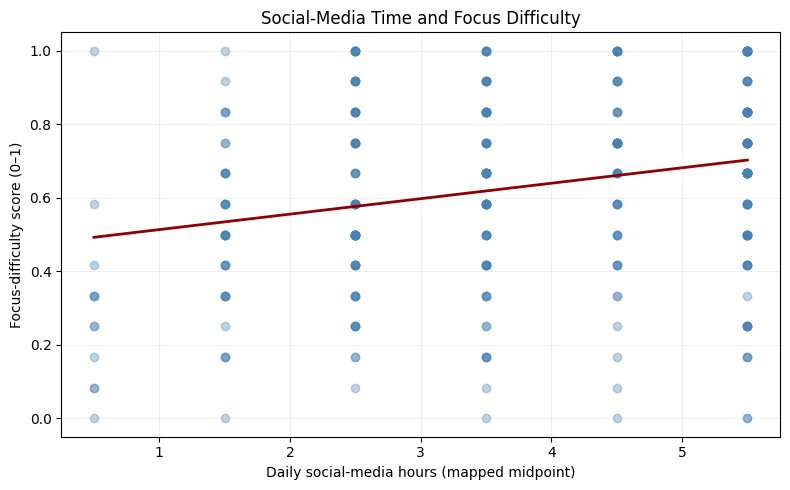

In [36]:
plt.figure(figsize=(8, 5))
plt.scatter(
    q1["daily_social_media_hours"],
    q1["focus_difficulty_score"],
    alpha=0.35,
    color="steelblue",
)

trend = np.poly1d(np.polyfit(
    q1["daily_social_media_hours"],
    q1["focus_difficulty_score"],
    1,
))
x_values = np.sort(q1["daily_social_media_hours"].unique())
plt.plot(x_values, trend(x_values), color="darkred", linewidth=2)
plt.xlabel("Daily social-media hours (mapped midpoint)")
plt.ylabel("Focus-difficulty score (0–1)")
plt.title("Social-Media Time and Focus Difficulty")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### EDA1 Interpretation

Among 371 respondents, Pearson correlation is approximately 0.245 and Spearman correlation is approximately 0.235. Both indicate a weak positive association: respondents reporting more social-media time tend to report somewhat greater focus difficulty, but time alone does not track the score. The vertical bands occur because time was originally collected as ordered ranges and represented by midpoints.

## 4.3 EDA Question 2

**How is purposeless social-media use associated with focus difficulty?**

The five response levels are summarized separately. Pearson and Spearman correlations evaluate whether higher purposeless-use responses tend to occur with higher focus-difficulty scores.

In [37]:
q2 = df_clean[["purposeless_usage", "focus_difficulty_score"]].dropna().copy()

q2_group_summary = (
    q2.groupby("purposeless_usage")["focus_difficulty_score"]
    .agg(["count", "mean", "median", "std"])
    .reindex([1, 2, 3, 4, 5])
)
q2_pearson = q2["purposeless_usage"].corr(q2["focus_difficulty_score"])
q2_spearman = q2["purposeless_usage"].rank().corr(
    q2["focus_difficulty_score"].rank()
)

print(q2_group_summary.round(3).to_string())
print()
print(f"Pearson correlation: {q2_pearson:.3f}")
print(f"Spearman correlation: {q2_spearman:.3f}")
print(f"Complete observations: {len(q2)}")

                   count   mean  median    std
purposeless_usage                             
1                      8  0.302   0.292  0.292
2                     41  0.480   0.500  0.224
3                     96  0.550   0.583  0.231
4                    136  0.683   0.708  0.232
5                     90  0.724   0.750  0.239

Pearson correlation: 0.377
Spearman correlation: 0.369
Complete observations: 371


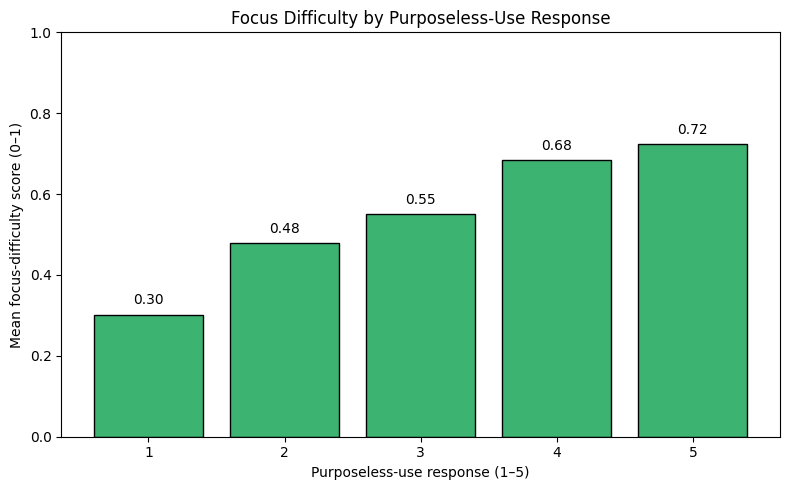

In [38]:
plt.figure(figsize=(8, 5))
bars = plt.bar(
    q2_group_summary.index.astype(str),
    q2_group_summary["mean"],
    color="mediumseagreen",
    edgecolor="black",
)
plt.ylim(0, 1)
plt.xlabel("Purposeless-use response (1–5)")
plt.ylabel("Mean focus-difficulty score (0–1)")
plt.title("Focus Difficulty by Purposeless-Use Response")

for bar, value in zip(bars, q2_group_summary["mean"]):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.025, f"{value:.2f}", ha="center")

plt.tight_layout()
plt.show()

### EDA2 Interpretation

Purposeless use has a positive Pearson correlation of approximately 0.377 and Spearman correlation of approximately 0.369 with focus difficulty. Mean focus difficulty rises from about 0.302 at response level 1 to 0.724 at level 5. The association is stronger than the relationship with daily hours, which suggests that how respondents use social media may be more informative than duration alone.

## 4.4 EDA Question 3

**How is restlessness when unable to use social media associated with focus difficulty?**

Restlessness is a separate five-point behavioral response and is not part of the focus score. Group summaries and correlations evaluate whether respondents reporting greater restlessness also tend to report greater distraction and concentration difficulty.

In [39]:
q3 = df_clean[["restlessness_score", "focus_difficulty_score"]].dropna().copy()

q3_group_summary = (
    q3.groupby("restlessness_score")["focus_difficulty_score"]
    .agg(["count", "mean", "median", "std"])
    .reindex([1, 2, 3, 4, 5])
)
q3_pearson = q3["restlessness_score"].corr(q3["focus_difficulty_score"])
q3_spearman = q3["restlessness_score"].rank().corr(
    q3["focus_difficulty_score"].rank()
)

print(q3_group_summary.round(3).to_string())
print()
print(f"Pearson correlation: {q3_pearson:.3f}")
print(f"Spearman correlation: {q3_spearman:.3f}")
print(f"Complete observations: {len(q3)}")

                    count   mean  median    std
restlessness_score                             
1                      76  0.391   0.417  0.230
2                      99  0.591   0.583  0.215
3                      93  0.707   0.750  0.195
4                      62  0.702   0.750  0.216
5                      41  0.866   0.917  0.171

Pearson correlation: 0.536
Spearman correlation: 0.537
Complete observations: 371


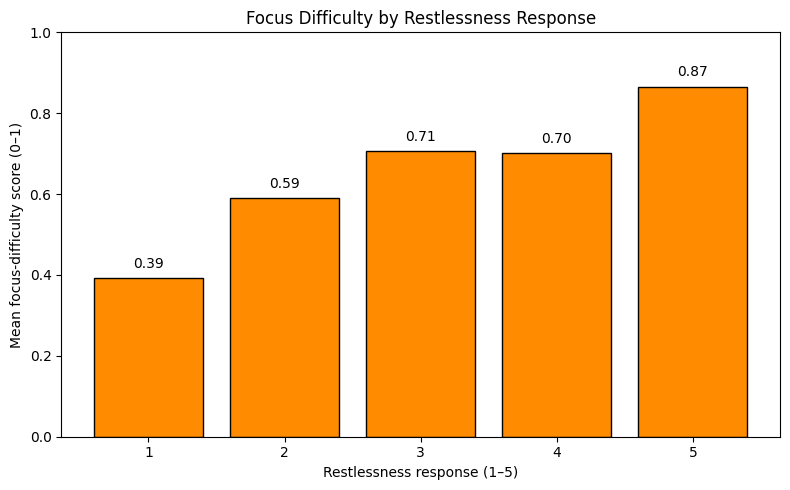

In [40]:
plt.figure(figsize=(8, 5))
bars = plt.bar(
    q3_group_summary.index.astype(str),
    q3_group_summary["mean"],
    color="darkorange",
    edgecolor="black",
)
plt.ylim(0, 1)
plt.xlabel("Restlessness response (1–5)")
plt.ylabel("Mean focus-difficulty score (0–1)")
plt.title("Focus Difficulty by Restlessness Response")

for bar, value in zip(bars, q3_group_summary["mean"]):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.025, f"{value:.2f}", ha="center")

plt.tight_layout()
plt.show()

### EDA3 Interpretation

Restlessness has a Pearson correlation of approximately 0.536 and Spearman correlation of approximately 0.537 with focus difficulty. This is the strongest of the three EDAs. Mean focus difficulty is about 0.391 at restlessness level 1 and 0.866 at level 5. The pattern is moderate and potentially influenced by shared self-reporting or other unmeasured factors.

# 5. Data Mining

## 5.1 Technique Selection

Association-rule mining is selected because each respondent can be represented as a basket of high-level behavioral items.

## 5.2 Transaction Representation

Four binary items are constructed from existing variables. `High time` means at least 4.5 mapped hours. `High purposeless use` and `High restlessness` mean responses of 4–5. `High focus difficulty` means a normalized score of at least 0.75, equivalent to an average original focus-item response of at least 4. These thresholds create interpretable baskets without adding respondents or outside variables.

In [41]:
transaction_items = pd.DataFrame({
    "High time": df_clean["daily_social_media_hours"] >= HIGH_TIME_MIN,
    "High purposeless use": df_clean["purposeless_usage"] >= 4,
    "High restlessness": df_clean["restlessness_score"] >= 4,
    "High focus difficulty": df_clean["focus_difficulty_score"] >= 0.75,
}, index=df_clean.index)

item_prevalence = pd.DataFrame({
    "count": transaction_items.sum(),
    "proportion": transaction_items.mean(),
}).sort_values("proportion", ascending=False)

print(f"Transactions: {len(transaction_items)}")
print(item_prevalence.round(3).to_string())

Transactions: 371
                       count  proportion
High purposeless use     226       0.609
High time                164       0.442
High focus difficulty    153       0.412
High restlessness        103       0.278


## 5.3 Frequent Itemsets

The minimum support threshold is 0.15, requiring an itemset to appear in at least about 56 of 371 respondents. This balances pattern frequency with a compact output. All one-, two-, and three-item combinations are checked using the brute-force process described in the association-rule lecture. The threshold is a mining choice, not a p-value or statistical-significance criterion.

In [42]:
support_threshold = 0.15
frequent_itemset_rows = []

for itemset_size in [1, 2, 3]:
    for itemset in combinations(transaction_items.columns, itemset_size):
        itemset_count = int(transaction_items[list(itemset)].all(axis=1).sum())
        itemset_support = itemset_count / len(transaction_items)
        if itemset_support >= support_threshold:
            frequent_itemset_rows.append({
                "itemset": " + ".join(itemset),
                "size": itemset_size,
                "count": itemset_count,
                "support": itemset_support,
            })

frequent_itemsets = (
    pd.DataFrame(frequent_itemset_rows)
    .sort_values(["size", "support"], ascending=[True, False])
    .reset_index(drop=True)
)

print(frequent_itemsets.round(3).to_string(index=False))

                                                         itemset  size  count  support
                                            High purposeless use     1    226    0.609
                                                       High time     1    164    0.442
                                           High focus difficulty     1    153    0.412
                                               High restlessness     1    103    0.278
                    High purposeless use + High focus difficulty     2    119    0.321
                                High time + High purposeless use     2    118    0.318
                               High time + High focus difficulty     2     84    0.226
                        High purposeless use + High restlessness     2     75    0.202
                       High restlessness + High focus difficulty     2     68    0.183
                                   High time + High restlessness     2     61    0.164
        High time + High purposeless use + 

## 5.4 Rule Generation

Rules use `High focus difficulty` as the consequent because the refined question concerns focus. Antecedents contain one or two social-media-use items. A rule is retained when the combined itemset has support of at least 0.15 and the rule has confidence of at least 0.60. Confidence is the proportion of respondents with the antecedent who also have high focus difficulty.

In [43]:
confidence_threshold = 0.60
consequent = "High focus difficulty"
antecedent_items = ["High time", "High purposeless use", "High restlessness"]
rule_rows = []

for antecedent_size in [1, 2]:
    for antecedent in combinations(antecedent_items, antecedent_size):
        antecedent_mask = transaction_items[list(antecedent)].all(axis=1)
        combined_mask = antecedent_mask & transaction_items[consequent]
        antecedent_count = int(antecedent_mask.sum())
        combined_count = int(combined_mask.sum())
        support = combined_count / len(transaction_items)
        confidence = combined_count / antecedent_count

        if support >= support_threshold and confidence >= confidence_threshold:
            rule_rows.append({
                "rule": f"{{{' + '.join(antecedent)}}} -> {{{consequent}}}",
                "antecedent_count": antecedent_count,
                "combined_count": combined_count,
                "support": support,
                "confidence": confidence,
            })

association_rules = (
    pd.DataFrame(rule_rows)
    .sort_values(["confidence", "support"], ascending=False)
    .reset_index(drop=True)
)

print(association_rules.round(3).to_string(index=False))

                                                                 rule  antecedent_count  combined_count  support  confidence
{High purposeless use + High restlessness} -> {High focus difficulty}                75              56    0.151       0.747
                       {High restlessness} -> {High focus difficulty}               103              68    0.183       0.660


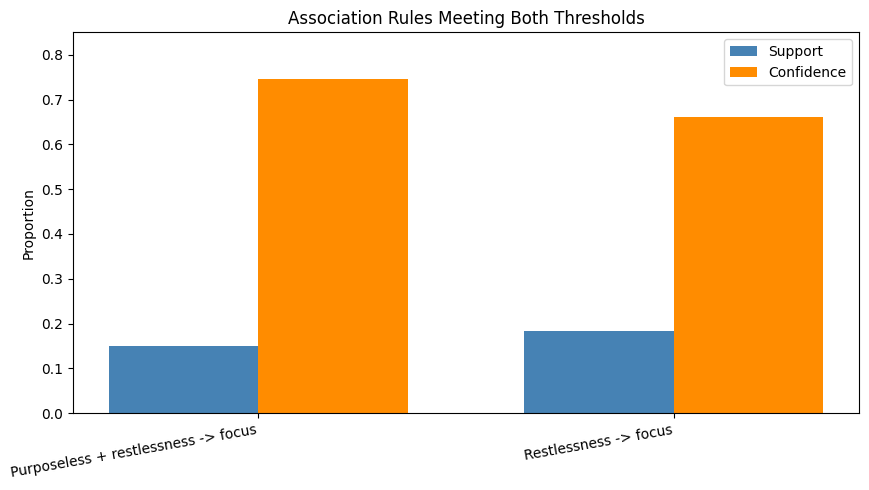

In [44]:
rule_labels = [
    "Purposeless + restlessness -> focus",
    "Restlessness -> focus",
]
rule_plot = association_rules.copy()
rule_plot["short_rule"] = rule_labels[:len(rule_plot)]

x = np.arange(len(rule_plot))
width = 0.36

plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, rule_plot["support"], width, label="Support", color="steelblue")
plt.bar(x + width / 2, rule_plot["confidence"], width, label="Confidence", color="darkorange")
plt.xticks(x, rule_plot["short_rule"], rotation=10, ha="right")
plt.ylim(0, 0.85)
plt.ylabel("Proportion")
plt.title("Association Rules Meeting Both Thresholds")
plt.legend()
plt.tight_layout()
plt.show()

### Draft Interpretation for Group Review

Two rules meet both thresholds. `{High restlessness} → {High focus difficulty}` has support 0.183 and confidence 0.660. `{High purposeless use + High restlessness} → {High focus difficulty}` has support 0.151 and confidence 0.747. Thus, the combined high-behavior pattern is less common but more consistently accompanied by high focus difficulty. Association rules describe co-occurrence and do not establish direction.

# 6. Statistical Inference

## 6.1 Inference Plan and Shared Assumptions

The significance level is `α = 0.05`. Two one-way ANOVA tests compare mean focus across independent groups; significant results are followed by pairwise independent t-tests using the course's Bonferroni correction. A chi-square test evaluates categorical independence. Each row represents one respondent, so observations are treated as independent. The inference is frequentist because these questions directly match the supplied means and categorical-data lessons.

In [45]:
alpha = 0.05

time_hours = df_clean["daily_social_media_hours"]
time_group_values = np.select(
    [
        time_hours <= LOW_TIME_MAX,
        (time_hours > LOW_TIME_MAX) & (time_hours < HIGH_TIME_MIN),
        time_hours >= HIGH_TIME_MIN,
    ],
    ["Low", "Moderate", "High"],
    default=None,
)
df_clean["time_group"] = pd.Categorical(
    time_group_values,
    categories=["Low", "Moderate", "High"],
    ordered=True,
)

df_clean["purposeless_group"] = pd.cut(
    df_clean["purposeless_usage"],
    bins=[0, 2, 3, 5],
    labels=["Low", "Neutral", "High"],
    include_lowest=True,
)
df_clean["restlessness_group"] = pd.cut(
    df_clean["restlessness_score"],
    bins=[0, 2, 3, 5],
    labels=["Low", "Neutral", "High"],
    include_lowest=True,
)
df_clean["focus_category"] = np.where(
    df_clean["focus_difficulty_score"] >= 0.75,
    "High focus difficulty",
    "Lower focus difficulty",
)

for group_column in ["time_group", "purposeless_group"]:
    print(group_column)
    print(
        df_clean.groupby(group_column, observed=False)["focus_difficulty_score"]
        .agg(["count", "mean", "median", "std"])
        .round(3)
        .to_string()
    )
    print()

time_group
            count   mean  median    std
time_group                             
Low           126  0.558   0.500  0.255
Moderate       81  0.635   0.667  0.244
High          164  0.679   0.750  0.244

purposeless_group
                   count   mean  median    std
purposeless_group                             
Low                   49  0.451   0.500  0.242
Neutral               96  0.550   0.583  0.231
High                 226  0.699   0.750  0.235



### ANOVA Assumption Check

The Q-Q plots assess within-group normality, as demonstrated in the foundations notebook. The focus score is bounded and discrete, so perfect normality is not expected. However, every ANOVA group has at least 49 respondents, allowing the course's Central Limit Theorem argument for group means. Standard deviations are also similar: approximately 0.244–0.255 for time groups and 0.231–0.242 for purposeless-use groups.

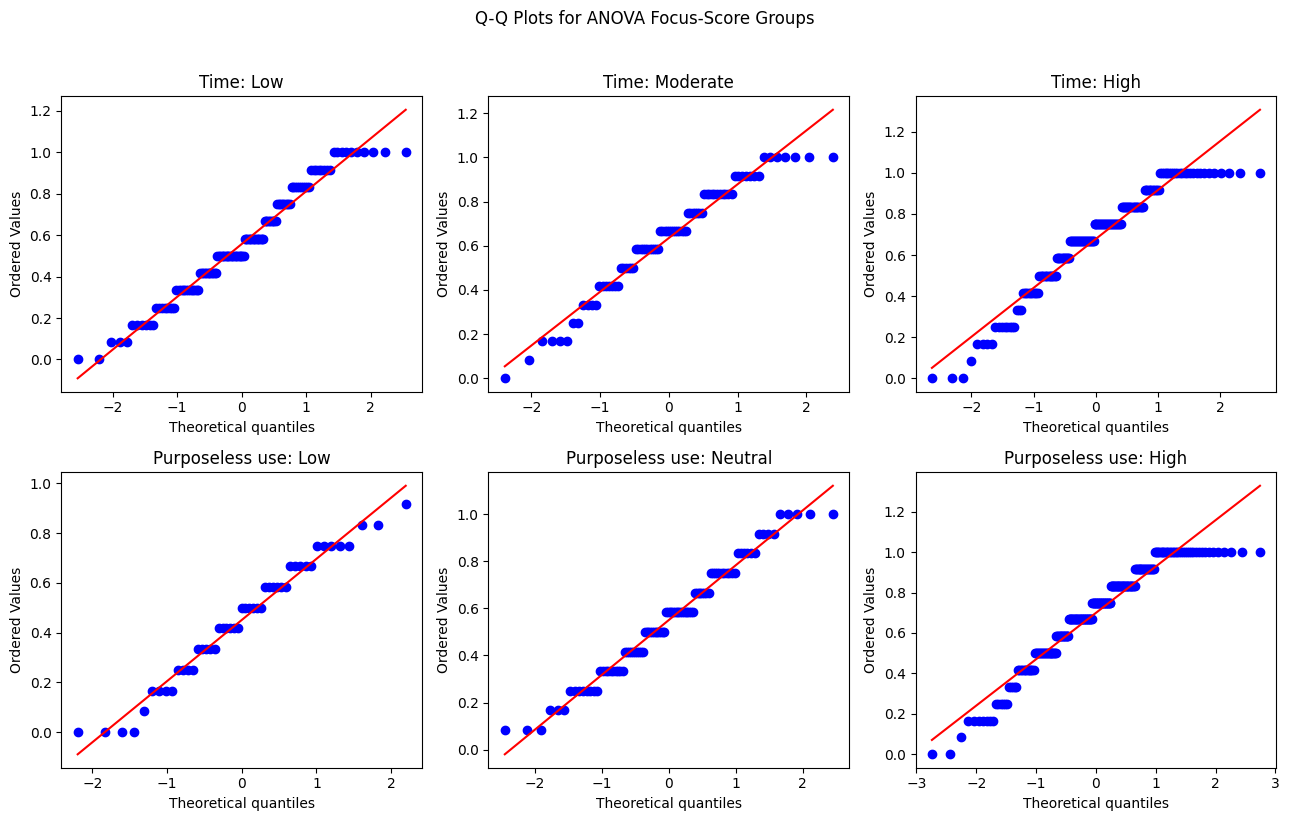

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for column_index, group_name in enumerate(["Low", "Moderate", "High"]):
    time_values = df_clean.loc[
        df_clean["time_group"] == group_name,
        "focus_difficulty_score",
    ]
    stats.probplot(time_values, dist=stats.norm(), plot=axes[0, column_index])
    axes[0, column_index].set_title(f"Time: {group_name}")

for column_index, group_name in enumerate(["Low", "Neutral", "High"]):
    purposeless_values = df_clean.loc[
        df_clean["purposeless_group"] == group_name,
        "focus_difficulty_score",
    ]
    stats.probplot(purposeless_values, dist=stats.norm(), plot=axes[1, column_index])
    axes[1, column_index].set_title(f"Purposeless use: {group_name}")

plt.suptitle("Q-Q Plots for ANOVA Focus-Score Groups", y=1.02)
plt.tight_layout()
plt.show()

## 6.2 Test 1: Mean Focus Across Social-Media-Time Groups

- **H₀:** Mean focus difficulty is equal across low, moderate, and high time groups.
- **Hₐ:** At least one group mean differs.

A one-way ANOVA is used because one numerical outcome is compared across three independent groups. The groups contain 126, 137, and 108 respondents, with similar standard deviations.

In [47]:
time_focus_groups = [
    df_clean.loc[df_clean["time_group"] == group, "focus_difficulty_score"]
    for group in ["Low", "Moderate", "High"]
]

time_f_stat, time_p_value = stats.f_oneway(*time_focus_groups)

print(f"F-statistic: {time_f_stat:.4f}")
print(f"p-value: {time_p_value:.8f}")
print("Decision:", "Reject H0" if time_p_value < alpha else "Fail to reject H0")

F-statistic: 8.5928
p-value: 0.00022528
Decision: Reject H0


In [48]:
def bonferroni_pairwise_tests(data, group_column, ordered_groups):
    comparisons = list(combinations(ordered_groups, 2))
    modified_alpha = alpha / len(comparisons)
    rows = []

    for group_a, group_b in comparisons:
        values_a = data.loc[data[group_column] == group_a, "focus_difficulty_score"]
        values_b = data.loc[data[group_column] == group_b, "focus_difficulty_score"]
        t_stat, p_value = stats.ttest_ind(values_a, values_b)
        rows.append({
            "comparison": f"{group_a} vs {group_b}",
            "t_statistic": t_stat,
            "p_value": p_value,
            "modified_alpha": modified_alpha,
            "significant_after_bonferroni": p_value < modified_alpha,
        })

    return pd.DataFrame(rows)

time_pairwise = bonferroni_pairwise_tests(
    df_clean,
    "time_group",
    ["Low", "Moderate", "High"],
)
print(time_pairwise.round(6).to_string(index=False))

      comparison  t_statistic  p_value  modified_alpha  significant_after_bonferroni
 Low vs Moderate    -2.163948 0.031625        0.016667                         False
     Low vs High    -4.117624 0.000050        0.016667                          True
Moderate vs High    -1.332306 0.184008        0.016667                         False


### Test 1 Interpretation

ANOVA gives `F ≈ 8.593` and `p ≈ 0.00023`, so equal means are rejected at `α = 0.05`. With Bonferroni-adjusted `α ≈ 0.0167`, only the low-time and high-time groups differ significantly (`p ≈ 0.00005`). The low-versus-moderate (`p ≈ 0.03163`) and moderate-versus-high (`p ≈ 0.18401`) comparisons are not significant after correction. Mean focus difficulty is therefore significantly higher among high-time users than low-time users, but the pairwise results do not support a clear step-by-step increase across all three groups.

## 6.3 Test 2: Mean Focus Across Purposeless-Use Groups

- **H₀:** Mean focus difficulty is equal across low, neutral, and high purposeless-use groups.
- **Hₐ:** At least one group mean differs.

A one-way ANOVA is appropriate for comparing the numerical focus score across three independent behavioral-response groups. Group sizes are 49, 96, and 226, with similar standard deviations.

In [49]:
purposeless_focus_groups = [
    df_clean.loc[df_clean["purposeless_group"] == group, "focus_difficulty_score"]
    for group in ["Low", "Neutral", "High"]
]

purposeless_f_stat, purposeless_p_value = stats.f_oneway(*purposeless_focus_groups)

print(f"F-statistic: {purposeless_f_stat:.4f}")
print(f"p-value: {purposeless_p_value:.14f}")
print("Decision:", "Reject H0" if purposeless_p_value < alpha else "Fail to reject H0")

F-statistic: 29.6230
p-value: 0.00000000000118
Decision: Reject H0


In [50]:
purposeless_pairwise = bonferroni_pairwise_tests(
    df_clean,
    "purposeless_group",
    ["Low", "Neutral", "High"],
)
print(purposeless_pairwise.round(6).to_string(index=False))

     comparison  t_statistic  p_value  modified_alpha  significant_after_bonferroni
 Low vs Neutral    -2.413945 0.017046        0.016667                         False
    Low vs High    -6.680512 0.000000        0.016667                          True
Neutral vs High    -5.231803 0.000000        0.016667                          True


### Test 2 Interpretation

ANOVA gives `F ≈ 29.623` and `p ≈ 1.18 × 10⁻¹²`, rejecting equal means. After Bonferroni correction, the high purposeless-use group differs significantly from both low and neutral groups. Low and neutral groups do not differ at the modified level. The supported contrast is therefore concentrated in respondents reporting high purposeless use.

## 6.4 Test 3: Restlessness and Categorized Focus Difficulty

- **H₀:** Restlessness group and focus-difficulty category are independent.
- **Hₐ:** Restlessness group and focus-difficulty category are dependent.

A chi-square test of independence is used because both variables are categorical. Restlessness responses are grouped as low (1–2), neutral (3), and high (4–5). High focus difficulty uses the same 0.75 threshold as association-rule mining.

In [51]:
restlessness_focus_table = pd.crosstab(
    df_clean["restlessness_group"],
    df_clean["focus_category"],
)

chi2_stat, chi2_p_value, chi2_dof, expected_counts = stats.chi2_contingency(
    restlessness_focus_table
)
expected_table = pd.DataFrame(
    expected_counts,
    index=restlessness_focus_table.index,
    columns=restlessness_focus_table.columns,
)

print("Observed counts:")
print(restlessness_focus_table.to_string())
print()
print("Expected counts:")
print(expected_table.round(2).to_string())
print()
print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {chi2_dof}")
print(f"p-value: {chi2_p_value:.14f}")
print(f"Minimum expected count: {expected_table.min().min():.2f}")
print("Decision:", "Reject H0" if chi2_p_value < alpha else "Fail to reject H0")

Observed counts:
focus_category      High focus difficulty  Lower focus difficulty
restlessness_group                                               
Low                                    38                     137
Neutral                                47                      46
High                                   68                      35

Expected counts:
focus_category      High focus difficulty  Lower focus difficulty
restlessness_group                                               
Low                                 72.17                  102.83
Neutral                             38.35                   54.65
High                                42.48                   60.52

Chi-square statistic: 56.9492
Degrees of freedom: 2
p-value: 0.00000000000043
Minimum expected count: 38.35
Decision: Reject H0


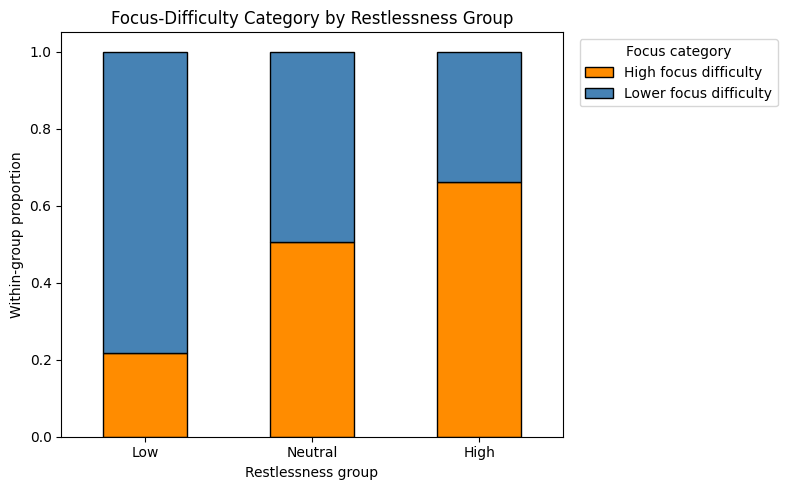

In [52]:
restlessness_focus_proportions = restlessness_focus_table.div(
    restlessness_focus_table.sum(axis=1),
    axis=0,
)

restlessness_focus_proportions.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=["darkorange", "steelblue"],
    edgecolor="black",
)
plt.xlabel("Restlessness group")
plt.ylabel("Within-group proportion")
plt.title("Focus-Difficulty Category by Restlessness Group")
plt.xticks(rotation=0)
plt.legend(title="Focus category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Test 3 Interpretation

The chi-square test gives `χ² ≈ 56.949`, `df = 2`, and `p ≈ 4.30 × 10⁻¹³`, so independence is rejected. Every expected count exceeds 38, satisfying the course requirement that expected counts not be too small. High focus difficulty appears in a larger share of the neutral and high restlessness groups than the low group. The result supports dependence, not causation.

# 7. Summary, Conclusions, and Recommendations

## 7.1 Summary

The study investigated the research question, "Which social-media-use patterns are associated with focus difficulty among young adults?" The analysis made use of the SMMH dataset only. The original dataset contained 481 observations. After conducting data cleaning, there are 371 respondents left. Daily social-media time was converted from ranges into midpoint values. A normalized focus-difficulty score was created by combining responses related to distraction while busy, generally destracted, and difficulty in concentrating.

Three EDA questions were asked and answered through descriptive statistics, Pearson and Spearman correlations, and visualizatoins. Daily social-media time had a weak positive association with focus diffculty. Purposeless use had a stronger possitive association, while restlessness after not using social media had the strongest association out of the three. EDA found a weak time–focus association, a stronger purposeless-use association, and the strongest relationship for restlessness.

Association-rule mining was applied by representing high time, purposeless use, restlessness, and focus difficulty as transaction items. Two rules were able to reach the support and confidence thresholds. High restlessness was frequently associated with high focus diffculty. Respondents with both high purposeless use and restlessness had a higher probability of reporting high focus diffculty.

Rule mining found that high restlessness, especially with high purposeless use, frequently co-occurred with high focus difficulty. ANOVA supported mean focus differences across time and purposeless-use groups. A second ANOVA found a significant differences acress purposeless-use groups because the high purposeless-use group had a higher focus difficulty. Finally, the Chi-square inference supported dependence between restlessness group and focus category. All analyses use the same 371 SMMH respondents.

## 7.2 Conclusions

First, time spent on social media had a statistically supported but limited relationship with focus difficulty. The main difference occurred between low use and the two higher-use groups. Moderate and high users did not differ significantly, which suggests that focus difficulty does not simply increase at the same rate as usage time.

Second, purposeless social-media use was more informative than duration alone. Respondents reporting high purposeless use had significantly greater focus difficulty than respondents in the low and neutral groups.

Third, restlessness was the strongest and most consistent pattern. It had the highest EDA correlation with focus difficulty, appeared in both retained association rules, and had a statistically significant relationship with categorized focus difficulty.

Overall, the results suggest that the manner in which young adults use social media may be more relevant to focus difficulty than total usage time alone. In particular, purposeless and restless use may identify respondents who are more likely to experience distraction and concentration problems.

These results demonstrate association and co-occurrence only. They do not prove that social media, purposeless use, or restlessness directly caused the reported focus difficulties.

## 7.3 Limitations

The data is self-reported, cross-sectional, and collected through an incompletely documented sampling process. Time midpoints and low/neutral/high thresholds simplify the original responses. ANOVA Q-Q plots reflect bounded, discrete scores, although group sizes are large and standard deviations are similar. Rule thresholds are analytical choices rather than significance tests. Multiple variables may reflect a shared tendency to report difficulty, and unmeasured workload, sleep, or prior attention conditions may influence results.

## 7.4 Recommendations

Young adults may benefit from monitoring purposeless or restless use patterns rather than focusing only on total hours. Researchers should use validated focus measures, clearer sampling methods, and longitudinal or experimental designs before making causal recommendations. The group should preserve the SMMH-only design, verify every output, and rewrite all draft interpretations in its own words before submission.

# 8. References and Disclosures

## 8.1 References

- SouvikAhmed071. (2023). *Social Media and Mental Health*. Kaggle. https://www.kaggle.com/datasets/souvikahmed071/social-media-and-mental-health

## 8.2 Generative AI Use Policy

During the preparation of this work, the author(s) used ChatGPT, Gemini for the following purposes:

ChatGPT/Codex - Generating code snippets on how to start formulating the code for data mining and statistical inference. Used in a way to help guide and correct initial code.
ChatGPT/Codex - Simplify the specifications for easier understanding.
ChatGPT/Codex - Double check revision plans made by the group, specifically if the route the group planned to take was a good pivot/direction to follow. (i.e. disregarding the other datasets and focus on smmh.csv)

After using this tool/service, the author(s) reviewed and edited the content as needed and take(s) full responsibility for the content of the publication.